In [1]:
import skrf as rf

from pmrf.models.lines import PhysicalCoaxial
from pmrf.parameter import norm, uniform, fixed
from pmrf.fitting import ScipyFitter
from pmrf._features import FeatureExtractor
from pmrf._modifiers import ModifierChain

# Create the model
coax = PhysicalCoaxial(name='coax')

wa, wb = 0.8, 1.2
params = {
    'din': uniform(1.12e-3*wa, 1.12e-3*wb),
    'dout': uniform(3.2e-3*wa, 3.2e-3*wb),
    'length': uniform(10*wa, 10*wb),
    'epr': uniform(1.45*wa, 1.45*wb),
    'tand': uniform(0.0, 0.1),
    'rho': uniform(1.6e-8*wa, 1.6e-8*wb),
}

measured = rf.Network('../examples/data/10m_cable.s2p', f_unit='MHz')

features = [
    FeatureExtractor(mode='complex', ports=(0, 0)), FeatureExtractor(mode='magnitude', ports=(0, 0)),
    FeatureExtractor(mode='complex', ports=(0, 1)), FeatureExtractor(mode='magnitude', ports=(0, 1)),
    FeatureExtractor(mode='complex', ports=(1, 0)), FeatureExtractor(mode='magnitude', ports=(1, 0)),
    FeatureExtractor(mode='complex', ports=(1, 1)), FeatureExtractor(mode='magnitude', ports=(1, 1))
]

# Initialize the fitter
fitter = ScipyFitter(
    model=coax,
    measured=measured,
    params=params,
    features=features,
)

print(fitter.cost())

[17.49039813]


In [3]:
fitter.fit()

********
[1.00e+01 1.12e-03 3.20e-03 1.45e+00 5.00e-02 1.60e-08]
********
Bounds(array([8.0400e+00, 9.0048e-04, 2.5728e-03, 1.1658e+00, 1.0000e-03,
       1.2864e-08]), array([1.19600e+01, 1.33952e-03, 3.82720e-03, 1.73420e+00, 9.90000e-02,
       1.91360e-08]))
********


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 3.4736320814995194
             x: [ 9.145e+00  1.340e-03  3.827e-03  1.681e+00  1.846e-03
                  1.914e-08]
           nit: 428
          nfev: 645
 final_simplex: (array([[ 9.145e+00,  1.340e-03, ...,  1.846e-03,
                         1.914e-08],
                       [ 9.145e+00,  1.340e-03, ...,  1.846e-03,
                         1.914e-08],
                       ...,
                       [ 9.145e+00,  1.340e-03, ...,  1.845e-03,
                         1.914e-08],
                       [ 9.145e+00,  1.340e-03, ...,  1.846e-03,
                         1.914e-08]]), array([ 3.474e+00,  3.474e+00,  3.474e+00,  3.474e+00,
                        3.474e+00,  3.474e+00,  3.474e+00]))

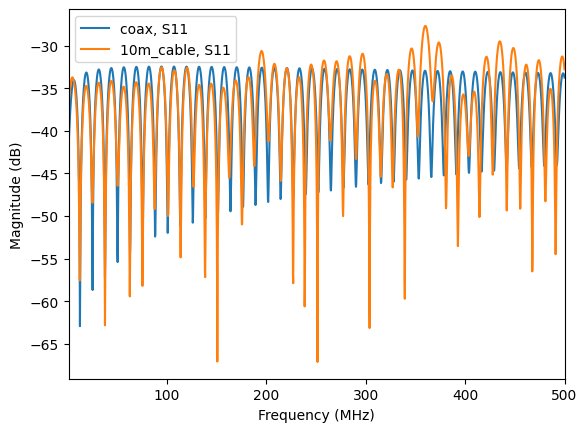

In [2]:
import matplotlib.pyplot as plt

plt.figure()
fitter.model.to_skrf(measured.frequency).plot_s_db(m=0, n=0)
measured.plot_s_db(m=0, n=0)
plt.show()